In [ ]:
import os, json
import numpy as np
import pandas as pd
from pathlib import Path

from joblib import dump, load
import lightgbm as lgb

from sklearn.calibration import CalibratedClassifierCV
from pandas.api.types import CategoricalDtype

# --- 2. Config ---
DATA_PARQUET = "Smart-Parking/parking_with_weather.parquet"
ARTIFACT_DIR = "Smart-Parking/models/parking_occ_lgbm"
PREDICTIONS_OUT = "Smart-Parking/predictions_optionA.parquet"

# Classification threshold for "busy/full"
THRESHOLD = 0.80   # define "busy" as >= 80% occupied

# Train/valid split and training params
SPLIT_DATE = "2024-11-01"      # validation starts here (UTC)
LOT_MIN_ROWS = 200

LEARNING_RATE = 0.05
NUM_LEAVES = 63
N_ESTIMATORS = 1200
EARLY_STOPPING = 100
VERBOSITY = 100

# --- 3. Utility Functions ---
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    ts = pd.to_datetime(df["timestamp_utc"], utc=True)
    df["hour"] = ts.dt.hour.astype("int16")
    df["dow"] = ts.dt.weekday.astype("int8")
    df["month"] = ts.dt.month.astype("int8")
    df["is_weekend"] = df["dow"].isin([5, 6]).astype("int8")
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24).astype("float32")
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24).astype("float32")
    return df

def add_rate_and_lags(df: pd.DataFrame) -> pd.DataFrame:
    if "occ_rate" not in df.columns:
        if "total_spaces" in df.columns and "occupied_spaces" in df.columns:
            cap = df["total_spaces"].replace(0, np.nan)
            df["occ_rate"] = (df["occupied_spaces"] / cap).clip(0, 1)
        else:
            df["occ_rate"] = np.nan
    df = df.sort_values(["external_id", "timestamp_utc"])
    df["occ_rate_lag1h"] = df.groupby("external_id", observed=False)["occ_rate"].shift(1)
    df["occ_rate_lag24h"] = df.groupby("external_id", observed=False)["occ_rate"].shift(24)
    df["occ_rate_roll3h"] = (
        df.groupby("external_id", observed=False)["occ_rate"]
        .rolling(window=3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    return df

def select_features(df: pd.DataFrame):
    base_feats = ["hour","dow","month","is_weekend","hour_sin","hour_cos","lat","lon","total_spaces"]
    weather = ["temperature_2m","relative_humidity_2m","precipitation","cloud_cover","wind_speed_10m","wind_direction_10m"]
    lags = ["occ_rate_lag1h","occ_rate_lag24h","occ_rate_roll3h"]
    feats = [f for f in base_feats if f in df.columns]
    feats += [w for w in weather if w in df.columns]
    feats += [l for l in lags if l in df.columns]
    if "external_id" in df.columns:
        df["external_id"] = df["external_id"].astype("category")
        feats.append("external_id")
    return feats

def set_global_external_id_categories(df: pd.DataFrame) -> CategoricalDtype:
    ids = sorted(df["external_id"].astype(str).unique())
    cat_dtype = CategoricalDtype(categories=ids, ordered=True)
    df["external_id"] = df["external_id"].astype(str).astype(cat_dtype)
    return cat_dtype

# --- 4. Prediction Functions (Single and Batch) ---
def load_artifacts_for_prediction(artifact_dir):
    """Load model, calibrator, and feature spec."""
    art = Path(artifact_dir)
    spec = json.loads((art / "feature_spec.json").read_text())
    calibrator = load(art / "calibrator.joblib")
    model = lgb.Booster(model_file=str(art / "model.txt"))
    return model, calibrator, spec

def prepare_single_input(df_row, spec):
    """
    Take a single-row DataFrame containing:
       external_id, timestamp_utc, lat, lon, total_spaces,
       (optional) weather columns,
       (optional) actual occ_rate or lags (if historical)
    and build all required feature columns.
    """
    FEATURES = spec["features"]
    TRAIN_CATS = spec["external_id_categories"]

    # Ensure correct dtypes
    df = df_row.copy()
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = add_time_features(df)

    # Insert empty lag columns if missing
    for lag in ["occ_rate_lag1h", "occ_rate_lag24h", "occ_rate_roll3h"]:
        if lag not in df.columns:
            df[lag] = np.nan

    # Ensure category dtype
    cat_dtype = CategoricalDtype(categories=TRAIN_CATS, ordered=True)
    df["external_id"] = df["external_id"].astype(str).astype(cat_dtype)

    # Ensure all features exist
    for f in FEATURES:
        if f not in df.columns:
            df[f] = np.nan

    return df[FEATURES], df

def predict_single(df_row, artifact_dir):
    """
    Given a prepared input row:
      - computes features
      - predicts p_busy
      - computes predicted_occupied & predicted_free
    """
    model, calibrator, spec = load_artifacts_for_prediction(artifact_dir)
    FEATURES = spec["features"]

    X_feats, full_df = prepare_single_input(df_row, spec)

    # Probability of busy
    p = calibrator.predict_proba(X_feats)[:, 1].item()

    # Convert to counts
    cap = full_df["total_spaces"].iloc[0]
    if pd.isna(cap):
        occ, free = None, None
    else:
        occ = int(np.clip(round(p * int(cap)), 0, int(cap)))
        free = int(cap) - occ

    out = full_df.copy()
    out["p_busy"] = p
    out["predicted_occupied"] = occ
    out["predicted_free"] = free

    return out

def load_all_artifacts_for_batch_prediction(artifact_dir):
    """Load all models, calibrators, and feature specs required for batch prediction."""
    art = Path(artifact_dir)

    # Load main feature spec and calibrator for the primary threshold
    spec = json.loads((art / "feature_spec.json").read_text())
    calibrator = load(art / "calibrator.joblib")

    # Load multi-threshold spec and individual calibrators
    spec_multi_path = art / "feature_spec_multi.json"
    if spec_multi_path.exists():
        spec_multi = json.loads(spec_multi_path.read_text())
    else:
        # Fallback if multi-threshold spec doesn't exist (e.g., if only Option A was trained)
        spec_multi = {
            "features": spec["features"],
            "external_id_categories": spec["external_id_categories"],
            "thresholds": [spec["threshold_occ_rate"]]
        }

    multi_calibrators = {}
    for t in spec_multi["thresholds"]:
        cal_path = art / f"calibrator_thr_{t:.2f}.joblib"
        if cal_path.exists():
            multi_calibrators[t] = load(cal_path)
        else:
            print(f"Warning: Missing calibrator for threshold {t:.2f}: {cal_path}")

    model = None
    return model, calibrator, spec, spec_multi, multi_calibrators

def prepare_batch_input(df_input, spec_multi):
    """
    Prepare the input DataFrame for batch prediction by adding time features,
    ensuring correct external_id categories, and confirming all required features
    (from spec_multi['features']) are present, filling missing ones with NaN if necessary.
    """
    df = df_input.copy()

    # Ensure timestamp_utc is datetime and add time features
    df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
    df = add_time_features(df)

    # Ensure category dtype for external_id
    if "external_id" in df.columns:
        if "external_id_categories" in spec_multi:
            string_categories = [str(cat) for cat in spec_multi["external_id_categories"]]
            cat_dtype = CategoricalDtype(categories=string_categories, ordered=True)
            df["external_id"] = df["external_id"].astype(str).astype(cat_dtype)
        else:
            print("Warning: 'external_id_categories' not found in spec_multi. Cannot categorize 'external_id' for batch prediction.")

    # Add placeholder lag columns if missing (if model expects them)
    for lag in ["occ_rate_lag1h", "occ_rate_lag24h", "occ_rate_roll3h"]:
        if lag not in df.columns:
            df[lag] = np.nan

    # Ensure all features exist and are in the correct order as per spec_multi
    FEATURES = spec_multi["features"]
    for f in FEATURES:
        if f not in df.columns:
            df[f] = np.nan

    X_feats = df[FEATURES]
    return df, X_feats

def predict_batch(df_input, artifact_dir):
    """
    Given an input DataFrame, computes features, predicts multi-threshold probabilities,
    enforces monotonicity, and calculates expected occupied/free spaces.
    """
    _, main_calibrator, spec, spec_multi, multi_calibrators = load_all_artifacts_for_batch_prediction(artifact_dir)

    df_processed, X_feats = prepare_batch_input(df_input, spec_multi)

    # Predict probabilities for each threshold
    THRS = sorted(spec_multi.get("thresholds", []))
    thr_cols = []

    if not THRS:
        print("No multi-thresholds defined in spec_multi. Using main calibrator for p_busy.")
        if "threshold_occ_rate" in spec and spec["threshold_occ_rate"] not in THRS:
            THRS.append(spec["threshold_occ_rate"])
            THRS = sorted(THRS)

    for t in THRS:
        col = f"p_ge_{int(t*100):02d}"
        if t in multi_calibrators:
            cal = multi_calibrators[t]
            df_processed[col] = cal.predict_proba(X_feats)[:, 1].astype("float32")
            thr_cols.append(col)
        elif "p_busy" not in df_processed.columns and t == spec["threshold_occ_rate"]:
            df_processed[col] = main_calibrator.predict_proba(X_feats)[:, 1].astype("float32")
            thr_cols.append(col)
        elif col not in df_processed.columns:
            print(f"Warning: Calibrator for threshold {t:.2f} not found and no main p_busy to fall back on. Skipping {col}.")
            df_processed[col] = np.nan

    if thr_cols:
        df_processed[thr_cols] = df_processed[thr_cols].cummin(axis=1)
    else:
        print("Warning: No valid threshold columns for monotonicity enforcement.")

    if thr_cols and not df_processed.empty:
        numerical_thresholds = sorted([float(c.split('_')[2])/100 for c in thr_cols if pd.notna(df_processed[c]).all()])

        if numerical_thresholds:
            grid = [0.0] + numerical_thresholds + [1.0]
            S0 = np.ones((len(df_processed), 1), dtype="float32")
            valid_Sthr_cols = [c for c in thr_cols if c in df_processed.columns and pd.notna(df_processed[c]).all()]
            Sthr = df_processed[valid_Sthr_cols].to_numpy(dtype="float32")
            S1 = np.zeros((len(df_processed), 1), dtype="float32")
            S = np.concatenate([S0, Sthr, S1], axis=1)

            grid = np.array(grid, dtype="float32")
            width = (grid[1:] - grid[:-1])
            S_avg = 0.5 * (S[:, :-1] + S[:, 1:])
            exp_occ_rate = (S_avg * width).sum(axis=1).astype("float32")
            df_processed["exp_occ_rate"] = exp_occ_rate
        else:
            df_processed["exp_occ_rate"] = np.nan
            print("Skipping expected occupancy rate calculation: No valid numerical thresholds found or all threshold columns contain NaNs.")
    else:
        df_processed["exp_occ_rate"] = np.nan
        print("Skipping expected occupancy rate calculation due to missing threshold data or empty DataFrame.")

    if "total_spaces" in df_processed.columns and "exp_occ_rate" in df_processed.columns:
        cap = df_processed["total_spaces"].astype("float32")
        df_processed["predicted_occupied"] = np.clip(np.round(df_processed["exp_occ_rate"] * cap), 0, cap).astype("Int64")
        df_processed["predicted_free"] = (cap - df_processed["predicted_occupied"].astype("float32")).astype("Int64")
    else:
        df_processed["predicted_occupied"] = pd.NA
        df_processed["predicted_free"] = pd.NA

    primary_thr_col = f"p_ge_{int(spec['threshold_occ_rate']*100):02d}"
    if primary_thr_col in df_processed.columns:
        df_processed["p_busy"] = df_processed[primary_thr_col]
    elif "p_busy" not in df_processed.columns:
        df_processed["p_busy"] = np.nan

    return df_processed


# --- 5. Data loading and preprocessing steps ---
print("Loading data...")
df = pd.read_parquet(DATA_PARQUET)
required = ["external_id","timestamp_utc","total_spaces"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

# Feature engineering
df = add_time_features(df)
df = add_rate_and_lags(df)

# Build Option A target
df["target"] = (df["occ_rate"] >= THRESHOLD).astype("int8")

# Global category alignment for external_id (pre-split)
cat_dtype = set_global_external_id_categories(df)
print("Data loaded and preprocessed.")


Mounted at /content/drive/
Loading data...
Data loaded and preprocessed.


### Prediction

## TODO

add current weather condition instead of historical using openmeteo


Lags probably need to lag a bit behind


---
What do we need as input?

Lot ID? location and total spaces - All of these are saved in "our" data

ALSO NEEDED - Occupancy rate from 3 hours ago -  24 hours ago and 1 hour ago



from time and location get weather conditions using openmeteo



In [ ]:

# --- 6. Single Prediction Demo for a parking lot 1-hour ahead ---
print("\nRunning single prediction demo...")
LOT_ID = "02e71643-9263-4ac9-9b9d-efe634811bd0" # Example LOT_ID

# Target prediction timestamp (e.g., 1 hour ahead from now, or a specific future time)
target_timestamp = pd.to_datetime("2025-11-16 11:00:00+00:00", utc=True)

# Extract static info (lat/lon/total_spaces) for the lot
lot_static_info = df[df["external_id"] == LOT_ID][["external_id", "lat", "lon", "total_spaces"]].iloc[-1]
if lot_static_info.empty:
    raise SystemExit(f"No static information found for LOT_ID='{LOT_ID}'. Please check the LOT_ID.")

# Prepare base input row
demo_input = pd.DataFrame({
    "external_id": [lot_static_info["external_id"]],
    "timestamp_utc": [target_timestamp],
    "lat": [lot_static_info["lat"]],
    "lon": [lot_static_info["lon"]],
    "total_spaces": [lot_static_info["total_spaces"]],
})

# --- Simulate dynamic features (weather, lags) using historical averages ---

# Extract time features from the target timestamp
demo_input['hour'] = demo_input['timestamp_utc'].dt.hour
demo_input['month'] = demo_input['timestamp_utc'].dt.month

# Calculate lot-specific hourly average occupancy rate from historical data
# Use observed=False to suppress FutureWarnings for categorical groupby
historical_lot_hourly_avg_occ_rate = df.groupby(['external_id', 'hour'], observed=False)['occ_rate'].mean().reset_index()

# Look up historical average occupancy rate for the specific lot and hour
occ_rate_at_hour = historical_lot_hourly_avg_occ_rate[
    (historical_lot_hourly_avg_occ_rate['external_id'] == LOT_ID) &
    (historical_lot_hourly_avg_occ_rate['hour'] == demo_input['hour'].iloc[0])
]['occ_rate']
demo_input['occ_rate'] = occ_rate_at_hour.iloc[0] if not occ_rate_at_hour.empty else df['occ_rate'].mean()

# Calculate monthly average weather values from historical data (global averages)
weather_features = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m']
weather_dfs = {
    feature: df.groupby('month', observed=False)[feature].mean().reset_index()
    for feature in weather_features
}

for feature in weather_features:
    # Look up the historical monthly average for the current month
    avg_val = weather_dfs[feature].loc[weather_dfs[feature]['month'] == demo_input['month'].iloc[0], feature]
    demo_input[feature] = avg_val.iloc[0] if not avg_val.empty else df[feature].mean()

# Since lags cannot be directly looked up from a single future point without a time series,
# we'll use historical averages of lags for the specific hour/lot from the df.
# This is an approximation for future input, ideally actual prior data would be used.
for lag_col in ["occ_rate_lag1h", "occ_rate_lag24h", "occ_rate_roll3h"]:
    # Get mean of existing lags for the specific lot and hour from historical data
    avg_lag_val = df.groupby(['external_id', 'hour'], observed=False)[lag_col].mean()
    lag_val = avg_lag_val.get((LOT_ID, demo_input['hour'].iloc[0]))
    demo_input[lag_col] = lag_val if pd.notna(lag_val) else df[lag_col].mean()

# Drop temporary columns used for simulation (if any)
demo_input.drop(columns=['hour', 'month', 'occ_rate'], inplace=True, errors='ignore')

# Ensure correct dtypes
demo_input["external_id"] = demo_input["external_id"].astype(str)
demo_input["timestamp_utc"] = pd.to_datetime(demo_input["timestamp_utc"], utc=True)
for col in ["lat", "lon", "total_spaces"] + weather_features + ["occ_rate_lag1h", "occ_rate_lag24h", "occ_rate_roll3h"]:
    if col in demo_input.columns:
        demo_input[col] = demo_input[col].astype("float32")


# Call predict_single with the prepared input
result = predict_single(demo_input, ARTIFACT_DIR)
print("Prediction for a single future timestamp:")
display(result.T)

Test with multibatch

In [ ]:
import numpy as np

# 1. Define the start and end dates for the future prediction window
START_FUTURE = "2025-05-01"
END_FUTURE = "2025-05-31"

# 2. Create a DataFrame with future timestamps
unique_lot_ids = df['external_id'].unique()
future_timestamps = pd.date_range(start=START_FUTURE, end=END_FUTURE, freq='h', tz='UTC')

future_data = []
for lot_id in unique_lot_ids:
    for timestamp in future_timestamps:
        future_data.append({'external_id': lot_id, 'timestamp_utc': timestamp})

future_df = pd.DataFrame(future_data)

# 3. Merge future_df with lot_static_info
lot_static_info = df[['external_id', 'lat', 'lon', 'total_spaces']].drop_duplicates('external_id')
future_df = pd.merge(future_df, lot_static_info, on='external_id', how='left')

# 4. Extract the hour and day of the week
future_df['hour'] = future_df['timestamp_utc'].dt.hour
future_df['day_of_week'] = future_df['timestamp_utc'].dt.day_name()

# --- MODIFIED SECTION for lot-specific average and noise ---
# Calculate lot-specific hourly average occupancy rate from historical data
# Use observed=False to suppress FutureWarnings for categorical groupby
historical_lot_hourly_avg_occ_rate = df.groupby(['external_id', 'hour'], observed=False)['occ_rate'].mean().reset_index()
historical_lot_hourly_avg_occ_rate = historical_lot_hourly_avg_occ_rate.rename(columns={'occ_rate': 'avg_occ_rate'})

# Merge future_df with historical lot-specific averages
future_df = pd.merge(future_df, historical_lot_hourly_avg_occ_rate, on=['external_id', 'hour'], how='left')

# Add Gaussian noise to the simulated occ_rate
NOISE_SCALE_OCC = 0.05 # Define noise scale
future_df['occ_rate'] = future_df['avg_occ_rate'] + np.random.normal(0, NOISE_SCALE_OCC, len(future_df))

# Clip the occupancy rate to be between 0 and 1
future_df['occ_rate'] = future_df['occ_rate'].clip(0, 1)

# Drop the temporary average column
future_df = future_df.drop(columns=['avg_occ_rate'])
# --- END MODIFIED SECTION ---

# Ensure future_df is sorted for lag calculation
future_df = future_df.sort_values(by=['external_id', 'timestamp_utc']).reset_index(drop=True)

# Recalculate lagged occupancy rates based on the new 'occ_rate'
# Using the add_rate_and_lags function if it's available and correctly handles
# the existing 'occ_rate' column. Otherwise, manual recalculation is done.
# Assuming add_rate_and_lags is available and functions correctly as per initial plan
# I will use the manual calculation to be explicit and avoid potential issues.
future_df['occ_rate_lag1h'] = future_df.groupby('external_id')['occ_rate'].shift(1)
future_df['occ_rate_lag24h'] = future_df.groupby('external_id')['occ_rate'].shift(24)
future_df['occ_rate_roll3h'] = (
    future_df.groupby('external_id')['occ_rate']
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

display(future_df.head())

,external_id,timestamp_utc,lat,lon,total_spaces,hour,day_of_week,occ_rate,occ_rate_lag1h,occ_rate_lag24h,occ_rate_roll3h
0,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 00:00:00+00:00,56.147095,10.196721,26,0,Thursday,0.925205,NaN,NaN,0.925205
1,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 01:00:00+00:00,56.147095,10.196721,26,1,Thursday,0.894898,0.925205,NaN,0.910051
2,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 02:00:00+00:00,56.147095,10.196721,26,2,Thursday,0.858359,0.894898,NaN,0.892821
3,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 03:00:00+00:00,56.147095,10.196721,26,3,Thursday,0.868698,0.858359,NaN,0.873985
4,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 04:00:00+00:00,56.147095,10.196721,26,4,Thursday,0.950900,0.868698,NaN,0.892652


In [ ]:
future_df['month'] = future_df['timestamp_utc'].dt.month

weather_features = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m']

# Calculate monthly average weather values from historical data
# Use observed=False to suppress FutureWarnings for categorical groupby
weather_dfs = {
    'temperature_2m': df.groupby('month', observed=False)['temperature_2m'].mean().reset_index(),
    'relative_humidity_2m': df.groupby('month', observed=False)['relative_humidity_2m'].mean().reset_index(),
    'precipitation': df.groupby('month', observed=False)['precipitation'].mean().reset_index(),
    'cloud_cover': df.groupby('month', observed=False)['cloud_cover'].mean().reset_index(),
    'wind_speed_10m': df.groupby('month', observed=False)['wind_speed_10m'].mean().reset_index(),
    'wind_direction_10m': df.groupby('month', observed=False)['wind_direction_10m'].mean().reset_index()
}

# Define noise scale for weather features
NOISE_SCALE_WEATHER = 2.0 # Adjust this value to control the amount of noise

for feature in weather_features:
    # Get the monthly average series for the current feature
    monthly_avg_series = weather_dfs[feature].set_index('month')[feature]

    # Map the monthly average to future_df based on 'month'
    future_df[f'{feature}_avg_temp'] = future_df['month'].map(monthly_avg_series)

    # Add Gaussian noise to the simulated weather feature
    future_df[feature] = future_df[f'{feature}_avg_temp'] + np.random.normal(0, NOISE_SCALE_WEATHER, size=len(future_df))

    # For precipitation, ensure values are not negative
    if feature == 'precipitation':
        future_df[feature] = future_df[feature].clip(lower=0)
    # For relative_humidity_2m, ensure values are between 0 and 100
    elif feature == 'relative_humidity_2m':
        future_df[feature] = future_df[feature].clip(lower=0, upper=100)
    # For cloud_cover, ensure values are between 0 and 100
    elif feature == 'cloud_cover':
        future_df[feature] = future_df[feature].clip(lower=0, upper=100)

    # Drop the temporary average column
    future_df.drop(columns=[f'{feature}_avg_temp'], inplace=True)

display(future_df.head())

,external_id,timestamp_utc,lat,lon,total_spaces,hour,day_of_week,occ_rate,occ_rate_lag1h,occ_rate_lag24h,occ_rate_roll3h,month,temperature_2m,relative_humidity_2m,precipitation,cloud_cover,wind_speed_10m,wind_direction_10m
0,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 00:00:00+00:00,56.147095,10.196721,26,0,Thursday,0.925205,NaN,NaN,0.925205,5,11.508800,81.878084,3.560695,46.553165,8.001436,143.247296
1,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 01:00:00+00:00,56.147095,10.196721,26,1,Thursday,0.894898,0.925205,NaN,0.910051,5,13.807978,79.799101,1.186123,46.061595,3.514922,142.618573
2,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 02:00:00+00:00,56.147095,10.196721,26,2,Thursday,0.858359,0.894898,NaN,0.892821,5,10.010152,76.683990,0.000000,44.222853,5.359879,145.778713
3,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 03:00:00+00:00,56.147095,10.196721,26,3,Thursday,0.868698,0.858359,NaN,0.873985,5,14.599445,77.269466,1.030331,47.244716,4.234120,142.100741
4,02e71643-9263-4ac9-9b9d-efe634811bd0,2025-05-01 04:00:00+00:00,56.147095,10.196721,26,4,Thursday,0.950900,0.868698,NaN,0.892652,5,15.739249,75.171489,2.103360,45.735596,4.329699,146.676126


[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 

,external_id,timestamp_utc,p_busy,exp_occ_rate,predicted_occupied,predicted_free,p_ge_20,p_ge_40,p_ge_60,p_ge_80
15141,761aebca-5045-4957-85f6-f883dfd36a46,2025-05-01 00:00:00+00:00,0.993026,0.897521,19,2,0.998961,0.998506,0.997111,0.993026
15142,761aebca-5045-4957-85f6-f883dfd36a46,2025-05-01 01:00:00+00:00,0.993020,0.897521,19,2,0.998961,0.998506,0.997119,0.993020
15143,761aebca-5045-4957-85f6-f883dfd36a46,2025-05-01 02:00:00+00:00,0.992941,0.897505,19,2,0.998961,0.998506,0.997115,0.992941
15144,761aebca-5045-4957-85f6-f883dfd36a46,2025-05-01 03:00:00+00:00,0.993110,0.897539,19,2,0.998961,0.998506,0.997119,0.993110
15145,761aebca-5045-4957-85f6-f883dfd36a46,2025-05-01 04:00:00+00:00,0.949598,0.888837,19,2,0.998961,0.998506,0.997119,0.949598


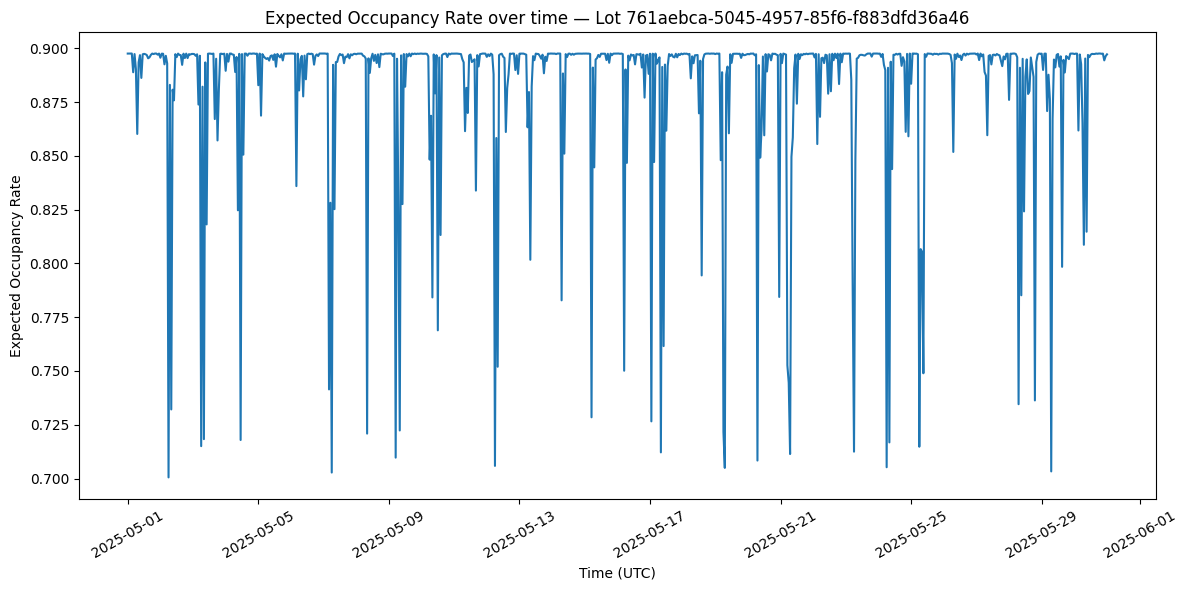

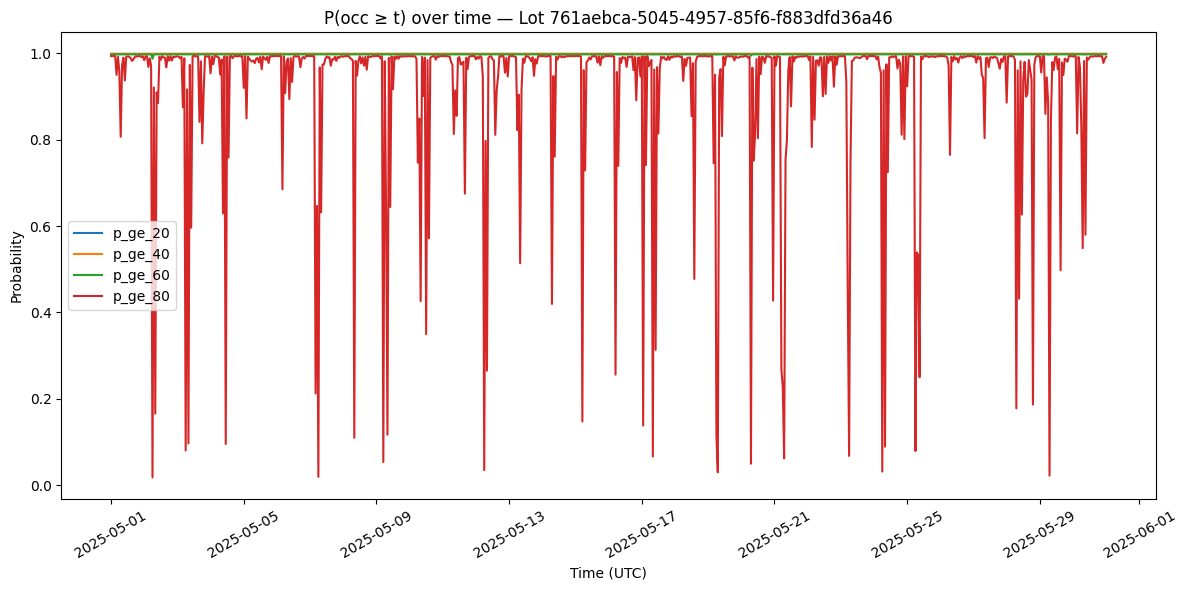


Diverse demo timestamps across dayparts (min & max exp_occ_rate per bucket):
                         external_id             timestamp_utc   p_busy  exp_occ_rate  predicted_occupied  predicted_free  p_ge_20  p_ge_40  p_ge_60  p_ge_80
761aebca-5045-4957-85f6-f883dfd36a46 2025-05-02 06:00:00+00:00 0.018490      0.700549                  15               6 0.998961 0.998506 0.986788 0.018490
761aebca-5045-4957-85f6-f883dfd36a46 2025-05-06 00:00:00+00:00 0.993126      0.897543                  19               2 0.998961 0.998506 0.997119 0.993126
761aebca-5045-4957-85f6-f883dfd36a46 2025-05-09 05:00:00+00:00 0.054159      0.709745                  15               6 0.998961 0.998506 0.997096 0.054159
761aebca-5045-4957-85f6-f883dfd36a46 2025-05-10 12:00:00+00:00 0.349948      0.768900                  16               5 0.998961 0.998506 0.997086 0.349948
761aebca-5045-4957-85f6-f883dfd36a46 2025-05-13 23:00:00+00:00 0.993126      0.897543                  19               2 0.998961 0

In [ ]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from joblib import load
from pandas.api.types import CategoricalDtype

# --- Config (edit) ---
ART_DIR = Path(ARTIFACT_DIR)  # reuse your earlier var, ensure it's a Path object
#LOT_ID = "02e71643-9263-4ac9-9b9d-efe634811bd0" # Example LOT_ID for visualization
LOT_ID = "761aebca-5045-4957-85f6-f883dfd36a46"
# The future_df has been generated for the period:
# START_FUTURE  = "2025-01-01"
# END_FUTURE    = "2025-01-31"

# Load the main dataframe (df) to get static lot info if needed for other purposes,
# but future_df already contains all necessary lot info from earlier steps.
if 'df' not in locals():
    raise SystemExit("Please run the cells to load the 'df' DataFrame first.")

# Ensure future_df exists from previous simulation steps
if 'future_df' not in locals():
    raise SystemExit("Please run the cells to generate the 'future_df' with simulated data first.")


# --- Use the predict_batch function with the enhanced future_df ---
# predict_batch will handle feature engineering (time + lags) and multi-threshold predictions internally
scored_future = predict_batch(future_df, ART_DIR)

# Filter for the specific LOT_ID for visualization as the original cell did
scored_future_filtered = scored_future[scored_future["external_id"] == LOT_ID].copy()

# Get threshold columns dynamically from the result
thr_cols = [col for col in scored_future_filtered.columns if col.startswith('p_ge_')]

# ---- Show a compact table ----
show_cols_base = ["external_id","timestamp_utc", "p_busy", "exp_occ_rate", "predicted_occupied","predicted_free"]
show_cols = show_cols_base + thr_cols
# Filter show_cols to only include columns that exist in scored_future_filtered
show_cols_existing = [col for col in show_cols if col in scored_future_filtered.columns]


if not scored_future_filtered.empty:
    # Sort by timestamp for better readability
    scored_future_filtered = scored_future_filtered.sort_values("timestamp_utc")
    display(scored_future_filtered[show_cols_existing].head())
else:
    print("No data to show for the selected lot and timestamps.")


# ---- Plot exp_occ_rate timeseries ----
if not scored_future_filtered.empty and "exp_occ_rate" in scored_future_filtered.columns:
  plt.figure(figsize=(12, 6))
  plt.plot(scored_future_filtered["timestamp_utc"], scored_future_filtered["exp_occ_rate"])
  plt.title(f"Expected Occupancy Rate over time \u2014 Lot {LOT_ID}")
  plt.xlabel("Time (UTC)"); plt.ylabel("Expected Occupancy Rate")
  plt.xticks(rotation=30); plt.tight_layout(); plt.show()
else:
  print("No data or 'exp_occ_rate' column to plot expected occupancy rate.")

# ---- Plot multi-threshold probabilities (overlay) ----
if not scored_future_filtered.empty and thr_cols:
  plt.figure(figsize=(12, 6))
  for c in thr_cols:
      # Ensure the threshold column exists before plotting
      if c in scored_future_filtered.columns:
          plt.plot(scored_future_filtered["timestamp_utc"], scored_future_filtered[c], label=c)
  plt.title(f"P(occ \u2265 t) over time \u2014 Lot {LOT_ID}")
  plt.xlabel("Time (UTC)"); plt.ylabel("Probability")
  plt.xticks(rotation=30); plt.tight_layout();
  plt.legend(); # Add legend to show which line is which threshold
  plt.show()
else:
  print("No data or threshold columns to plot multi-threshold probabilities.")


# ---- Pick a small demo set of diverse timestamps to show (one per bucket with extremes) ----
diverse = []
if not scored_future_filtered.empty and "exp_occ_rate" in scored_future_filtered.columns: # Use exp_occ_rate for diversity selection
  g = scored_future_filtered.copy()
  g["hour"] = g["timestamp_utc"].dt.hour
  g["weekday"] = g["timestamp_utc"].dt.day_name()
  g["tod_bucket"] = pd.cut(
      g["hour"],
      bins=[-0.5, 5.5, 11.5, 17.5, 23.5],
      labels=["Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]
  )

  # Ensure at least one row before trying to find min/max
  if not g.empty:
    for bucket, grp in g.groupby("tod_bucket", observed=False):
        if len(grp) == 0:
            continue
        # pick lowest and highest exp_occ_rate within the bucket
        diverse.append(grp.nsmallest(1, "exp_occ_rate")[show_cols_existing].iloc[0])
        diverse.append(grp.nlargest(1, "exp_occ_rate")[show_cols_existing].iloc[0])


  if diverse:
    demo_diverse = pd.DataFrame(diverse).sort_values("timestamp_utc")
    print("\nDiverse demo timestamps across dayparts (min & max exp_occ_rate per bucket):")
    print(demo_diverse.to_string(index=False))
  else:
    print("\nNo diverse demo timestamps to show based on exp_occ_rate.")
else:
  print("\nNo data or 'exp_occ_rate' column to show diverse demo timestamps.")

In [ ]:
# ============================================================
#   EVALUATE HOW GOOD THE PREDICTIONS ARE (PLUG & PLAY CELL)
# ============================================================

import numpy as np
import pandas as pd
from math import sqrt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# ------------------------------------------------------------
# 0. Basic checks
# ------------------------------------------------------------
if "df" not in locals():
    raise SystemExit(
        "DataFrame 'df' not found. "
        "Run the main preprocessing/model notebook cell first."
    )

if "predict_batch" not in globals():
    raise SystemExit(
        "'predict_batch' not found. "
        "Make sure the cell defining predict_batch has been run."
    )

if "THRESHOLD" not in globals():
    raise SystemExit(
        "'THRESHOLD' not defined. "
        "It is used to define when a lot is considered 'busy'."
    )

# ------------------------------------------------------------
# 1. Choose evaluation set (by time)
#    We use the validation period from SPLIT_DATE onwards.
#    If SPLIT_DATE fails, we fall back to all data.
# ------------------------------------------------------------
df_eval = df.copy()

try:
    eval_start_ts = pd.to_datetime(SPLIT_DATE).tz_localize("UTC")
    df_eval = df[df["timestamp_utc"] >= eval_start_ts].copy()
    print(f"Using evaluation window from {SPLIT_DATE} onwards.")
except Exception as e:
    print(f"Could not apply SPLIT_DATE ({e}). Using all rows for evaluation.")
    df_eval = df.copy()

# Keep only rows with valid occupancy information
df_eval = df_eval[
    df_eval["occ_rate"].notna() &
    df_eval["total_spaces"].notna()
].copy()

print(f"Rows in evaluation set with valid occ_rate & total_spaces: {len(df_eval)}")

if df_eval.empty:
    raise SystemExit("No rows left in evaluation set after filtering.")

# ------------------------------------------------------------
# 2. Run model to get predictions using the existing pipeline
# ------------------------------------------------------------
scored_eval = predict_batch(df_eval, ARTIFACT_DIR)

# Sanity check
if "p_busy" not in scored_eval.columns:
    raise SystemExit(
        "'p_busy' column not found in scored_eval. "
        "Check that predict_batch is working as expected."
    )

# ------------------------------------------------------------
# 3. Classification metrics:
#    - busy vs not busy, at THRESHOLD (e.g. 80% occupancy)
# ------------------------------------------------------------
mask_cls = scored_eval["p_busy"].notna() & scored_eval["occ_rate"].notna()
eval_cls = scored_eval.loc[mask_cls].copy()

if eval_cls.empty:
    raise SystemExit("No rows with valid p_busy and occ_rate for classification metrics.")

# True label: is lot busy (occ_rate >= THRESHOLD)?
y_true_cls = (eval_cls["occ_rate"] >= THRESHOLD).astype(int).values

# Predicted probability of being busy
y_prob_cls = eval_cls["p_busy"].values

# Predicted class using 0.5 probability cut-off
y_pred_cls = (y_prob_cls >= 0.5).astype(int)

print("\n================= CLASSIFICATION (BUSY / NOT BUSY) =================")
print(f"Threshold on occupancy rate (THRESHOLD): {THRESHOLD:.2f}")
print(f"Number of evaluated samples: {len(eval_cls)}\n")

print(f"Accuracy : {accuracy_score(y_true_cls, y_pred_cls):.4f}")
print(f"Precision: {precision_score(y_true_cls, y_pred_cls):.4f}")
print(f"Recall   : {recall_score(y_true_cls, y_pred_cls):.4f}")
print(f"F1-score : {f1_score(y_true_cls, y_pred_cls):.4f}")

try:
    roc = roc_auc_score(y_true_cls, y_prob_cls)
    print(f"ROC AUC  : {roc:.4f}")
except ValueError:
    print("ROC AUC  : could not be computed (only one class present).")

# Confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion matrix [rows=true, cols=pred]:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# ------------------------------------------------------------
# 4. Occupancy regression-style metrics:
#    - Compare predicted_occupied / exp_occ_rate vs actual
# ------------------------------------------------------------
mask_reg = (
    scored_eval["exp_occ_rate"].notna()
    & scored_eval["total_spaces"].notna()
    & scored_eval["occ_rate"].notna()
    & scored_eval["predicted_occupied"].notna()
)
eval_reg = scored_eval.loc[mask_reg].copy()

if not eval_reg.empty:
    # True and predicted occupancy rate
    y_true_rate = eval_reg["occ_rate"].values
    y_pred_rate = eval_reg["exp_occ_rate"].values

    mae_rate = mean_absolute_error(y_true_rate, y_pred_rate)
    rmse_rate = sqrt(mean_squared_error(y_true_rate, y_pred_rate))
    r2_rate = r2_score(y_true_rate, y_pred_rate)

    # Convert rates to absolute spaces
    cap = eval_reg["total_spaces"].values.astype(float)
    y_true_spaces = np.round(y_true_rate * cap)
    y_pred_spaces = eval_reg["predicted_occupied"].values.astype(float)

    mae_spaces = mean_absolute_error(y_true_spaces, y_pred_spaces)
    rmse_spaces = sqrt(mean_squared_error(y_true_spaces, y_pred_spaces))

    print("\n================= OCCUPANCY LEVEL (REGRESSION) =================")
    print(f"Number of evaluated samples: {len(eval_reg)}\n")

    print(f"MAE (occ_rate)         : {mae_rate:.4f}  (~{mae_rate*100:.2f} percentage points)")
    print(f"RMSE (occ_rate)        : {rmse_rate:.4f} (~{rmse_rate*100:.2f} percentage points)")
    print(f"R² (occ_rate)          : {r2_rate:.4f}")

    print(f"\nMAE (occupied spaces)  : {mae_spaces:.2f} spaces")
    print(f"RMSE (occupied spaces) : {rmse_spaces:.2f} spaces")
else:
    print("\nNo rows with valid exp_occ_rate / predicted_occupied for regression-style metrics.")


Using evaluation window from 2024-11-01 onwards.
Rows in evaluation set with valid occ_rate & total_spaces: 46464
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 

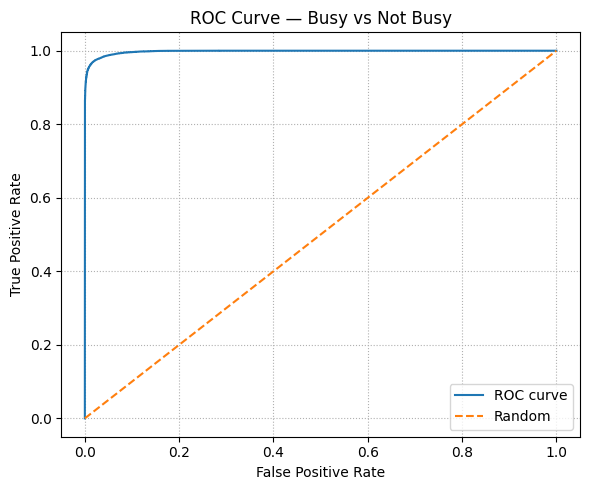

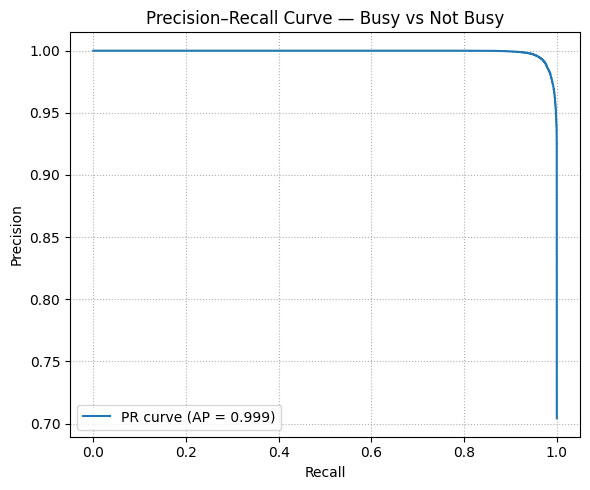

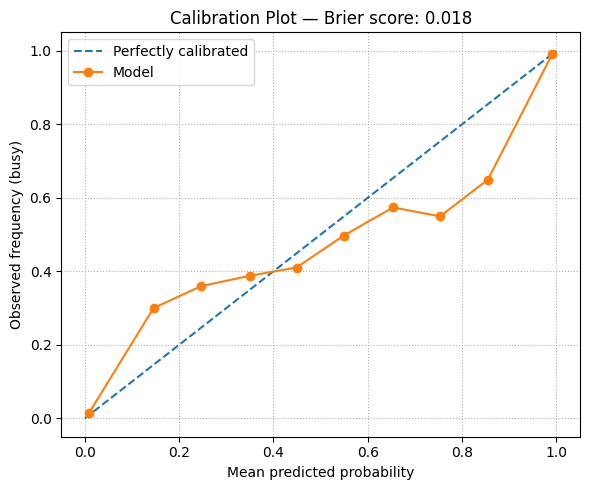

Calibration bin stats:
bin_center | mean_pred | true_rate | count
0.05	0.01	0.01	12789
0.15	0.15	0.30	310
0.25	0.25	0.36	192
0.35	0.35	0.39	134
0.45	0.45	0.41	156
0.55	0.55	0.50	167
0.65	0.65	0.57	190
0.75	0.75	0.55	202
0.85	0.85	0.65	308
0.95	0.99	0.99	32016


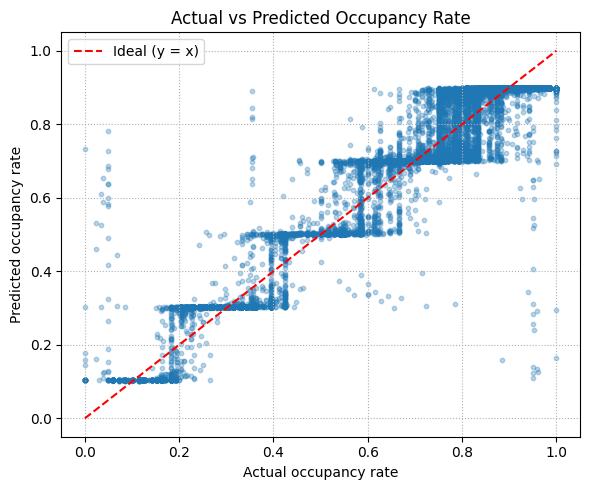

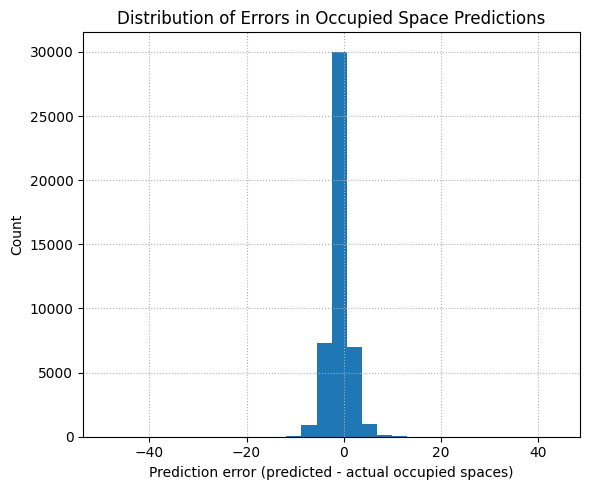

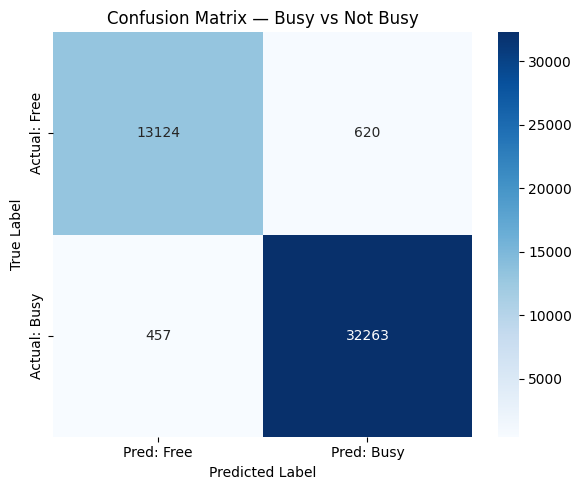

In [ ]:
# ============================================================
#   VISUALIZATIONS OF MODEL PERFORMANCE
#   - ROC curve
#   - Precision–Recall curve
#   - Calibration / reliability diagram
#   - Actual vs predicted occupancy rate
#   - Error histogram in occupied spaces
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss,
)

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------
needed_vars = ["eval_cls", "y_true_cls", "y_prob_cls", "y_pred_cls", "eval_reg"]
for v in needed_vars:
    if v not in globals():
        raise SystemExit(
            f"Variable '{v}' not found. "
            "Make sure you've run the evaluation cell first."
        )

# ============================================================
# 1) ROC CURVE
# ============================================================
fpr, tpr, roc_thresholds = roc_curve(y_true_cls, y_prob_cls)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Busy vs Not Busy")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

# ============================================================
# 2) PRECISION–RECALL CURVE
# ============================================================
prec, rec, pr_thresholds = precision_recall_curve(y_true_cls, y_prob_cls)
ap = average_precision_score(y_true_cls, y_prob_cls)

plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"PR curve (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Busy vs Not Busy")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3) CALIBRATION / RELIABILITY DIAGRAM
#    - Bin predicted probabilities and compare to true rate
# ============================================================
n_bins = 10
bins = np.linspace(0.0, 1.0, n_bins + 1)
bin_ids = np.digitize(y_prob_cls, bins) - 1  # bin indices [0..n_bins-1]

bin_centers = []
bin_true_rate = []
bin_pred_mean = []
bin_counts = []

for b in range(n_bins):
    mask = bin_ids == b
    if not np.any(mask):
        continue
    bin_p = y_prob_cls[mask]
    bin_y = y_true_cls[mask]
    bin_centers.append((bins[b] + bins[b+1]) / 2.0)
    bin_pred_mean.append(bin_p.mean())
    bin_true_rate.append(bin_y.mean())
    bin_counts.append(mask.sum())

bin_centers = np.array(bin_centers)
bin_true_rate = np.array(bin_true_rate)
bin_pred_mean = np.array(bin_pred_mean)

bs = brier_score_loss(y_true_cls, y_prob_cls)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], "--", label="Perfectly calibrated")
plt.plot(bin_pred_mean, bin_true_rate, "o-", label="Model")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency (busy)")
plt.title(f"Calibration Plot — Brier score: {bs:.3f}")
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

# Optionally, show bin counts
calib_table = (
    "Calibration bin stats:\n"
    "bin_center | mean_pred | true_rate | count\n" +
    "\n".join(
        f"{c:.2f}\t{pm:.2f}\t{tr:.2f}\t{cnt}"
        for c, pm, tr, cnt in zip(bin_centers, bin_pred_mean, bin_true_rate, bin_counts)
    )
)
print(calib_table)

# ============================================================
# 4) ACTUAL vs PREDICTED OCCUPANCY RATE
# ============================================================
if not eval_reg.empty:
    y_true_rate = eval_reg["occ_rate"].values
    y_pred_rate = eval_reg["exp_occ_rate"].values

    plt.figure(figsize=(6, 5))
    plt.scatter(y_true_rate, y_pred_rate, alpha=0.3, s=10)
    plt.plot([0, 1], [0, 1], "r--", label="Ideal (y = x)")
    plt.xlabel("Actual occupancy rate")
    plt.ylabel("Predicted occupancy rate")
    plt.title("Actual vs Predicted Occupancy Rate")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

    # ========================================================
    # 5) ERROR HISTOGRAM IN OCCUPIED SPACES
    # ========================================================
    # true and predicted occupied spaces from evaluation cell
    y_true_spaces = np.round(y_true_rate * eval_reg["total_spaces"].values.astype(float))
    y_pred_spaces = eval_reg["predicted_occupied"].values.astype(float)

    errors_spaces = y_pred_spaces - y_true_spaces

    plt.figure(figsize=(6, 5))
    plt.hist(errors_spaces, bins=30)
    plt.xlabel("Prediction error (predicted - actual occupied spaces)")
    plt.ylabel("Count")
    plt.title("Distribution of Errors in Occupied Space Predictions")
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()
else:
    print("eval_reg is empty — skipping occupancy-level visualizations.")



# =============================
# Confusion Matrix Visualization
# =============================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Free", "Pred: Busy"],
            yticklabels=["Actual: Free", "Actual: Busy"])
plt.title("Confusion Matrix — Busy vs Not Busy")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

